2026-01-16 09-34-02
Outputs will be written to: results/run_2026-01-16 09-34-02
Saved a copy of the config : results/run_2026-01-16 09-34-02/config_copy.yaml
Inputs shape: (31, 5)
Outputs shape: (31,)
First 20 rows of raw data:
       floor     sugar      eggs    butter      milk  flavour-score  source
20  0.733334  0.200000  0.666667  0.733334  0.133334      -0.537794  week-1
27  0.650000  0.200000  0.700000  0.700000  0.150000      -0.634927  week-8
22  0.667597  0.157201  0.738339  0.678368  0.179636      -0.683325  week-3
21  0.757576  0.101010  0.707071  0.757576  0.151515      -0.710242  week-2
0   0.728186  0.154693  0.732552  0.693997  0.056401      -0.714265    file
28  0.700000  0.150000  0.750000  0.700000  0.100000      -0.745342  week-9
4   0.618812  0.331802  0.187288  0.756238  0.328835      -0.829237    file
24  0.501329  0.211390  0.390924  0.970550  0.015922      -0.886618  week-5
17  0.782880  0.536336  0.443284  0.859700  0.010326      -0.935757    file
10  0.536797

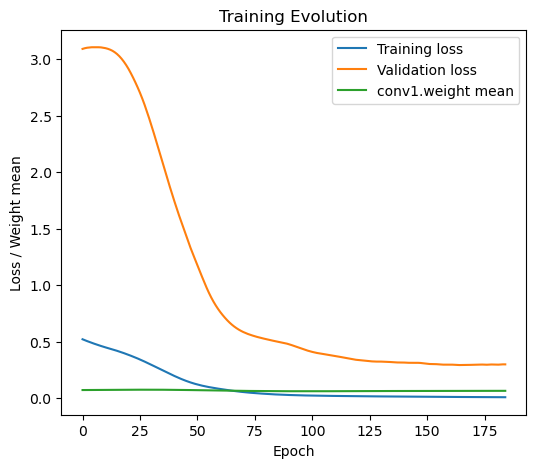

/opt/anaconda3/envs/tf-macos/lib/python3.10/site-packages/scipy/stats/_qmc.py:958: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)
sample_strategy=sobol, Final sample shape: (1000000, 5)
⚠️ No filtering applied to candidate grid
Total number of points to evaluate: 2
{'method': 'EI', 'xi': 0.0, 'kappa': None, 'x': array([1.11849914, 1.27072927, 1.10359696, 0.01493329, 1.08624182]), 'score': 0.17958230123720104, 'dim': 5, 'predicted_y': 3.416391, 'improvement_over_input_model': 0.21718073, 'distance_to_best_input': 1.0512375587382017}
{'method': 'EI', 'xi': 0.1, 'kappa': None, 'x': array([1.11849914, 1.27072927, 1.10359696, 0.01493329, 1.08624182]), 'score': 0.1514261466939386, 'dim': 5, 'predicted_y': 3.416391, 'improvement_over_input_model': 0.21718073, 'distance_to_best_input': 1.0512375587382017}

🔍 Best candidate (highest acquisition score):
Method: EI
xi: 0.0
Dimensions: 5
x: [1.118499, 1.270729, 1.10359

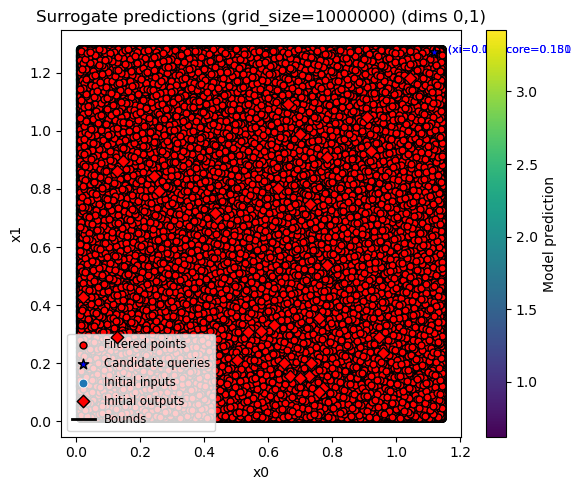

Saved dataframe to: results/run_2026-01-16 09-34-02/df_grid_1000000_stride5_None_max_negated_lr0.001_ep600.csv
Best candidate: {'method': 'EI', 'xi': 0.0, 'kappa': None, 'x': array([1.11849914, 1.27072927, 1.10359696, 0.01493329, 1.08624182]), 'score': 0.17958230123720104, 'dim': 5, 'predicted_y': 3.416391, 'improvement_over_input_model': 0.21718073, 'distance_to_best_input': 1.0512375587382017, 'best_input_x': array([1.044814, 1.182954, 0.060528, 0.012709, 1.023245]), 'best_input_pred': 3.1992102}
       floor     sugar      eggs    butter      milk  flavour-score   source  flavour-score-scaled
0   1.118499  1.270729  1.103597  0.014933  1.086242       0.179582   week-x             10.000000
1   1.118499  1.270729  1.103597  0.014933  1.086242       0.151426   week-x              8.432131
2   0.733334  0.200000  0.666667  0.733334  0.133334      -0.537794   week-1            -29.946952
3   0.650000  0.200000  0.700000  0.700000  0.150000      -0.634927   week-8            -35.355790
4

In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, setup_results_logging, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# set up logging to file
out_dir = setup_results_logging(cfg)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (6, 5)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh, out_dir=out_dir)

print("Pipeline finished. Results keys:", list(results.keys()))